In [1]:
# краткая документация по назначению ноутбука
"""
назначение: поиск peel chain паттернов в elliptic bitcoin transaction dataset.
основные шаги: загрузка csv, построение directed-графа, rule-based baseline,
unsupervised scoring цепочек, визуализация кандидатов и экспорт peel-признаков.
зависимости и источники: pandas, numpy, networkx, sklearn, matplotlib,
seaborn, torch, elliptic_txs_features.csv, elliptic_txs_edgelist.csv,
elliptic_txs_classes.csv.
ключевые переменные:
- graph: directed-граф транзакций, по которому строятся цепочки.
- chains: список найденных кандидатов peel chain с последовательностью txid.
- chain_table: таблица chain-level признаков, ошибок и итоговых score.
- sequence_tensor: тензор шагов цепочки для gru autoencoder.
- peel_features: node-level признаки участия txid в найденных цепочках.
принцип функций:
- поиск цепочек получает стартовый узел и ограничения, возвращает допустимые пути.
- sequence autoencoder получает признаки шагов, возвращает ошибку реконструкции цепочки.
- tabular anomaly detection получает агрегаты цепочек, возвращает anomaly score.
- экспорт признаков агрегирует chain-level score в node-level признаки для классификации.
гипотезы:
- peel chain отражает последовательное разделение потока на main-flow и боковые выходы.
- высокая ошибка реконструкции указывает на нетипичную форму цепочки.
- несколько независимых score устойчивее одной жёсткой эвристики.
"""

'\nназначение: поиск peel chain паттернов в Elliptic Bitcoin Transaction Dataset.\nосновные шаги: загрузка CSV, построение directed-графа, rule-based baseline,\nunsupervised scoring цепочек, визуализация кандидатов и экспорт peel-признаков.\nзависимости и источники: pandas, numpy, networkx, sklearn, matplotlib,\nseaborn, torch, elliptic_txs_features.csv, elliptic_txs_edgelist.csv,\nelliptic_txs_classes.csv.\n'

# 05 - Peel chains в Elliptic Dataset

Цель ноутбука — найти кандидаты на `peel chain` без ручной разметки. Используются четыре независимых подхода:

- rule-based baseline как жёсткая эвристика;
- sequence autoencoder по шаговым признакам цепочек;
- tabular anomaly detection по агрегированным признакам;
- subgraph encoder с anomaly detection в embedding-пространстве.

В конце результаты переводятся в признаки уровня транзакций и сохраняются в `peel_features.csv` для дальнейшей node classification.

## 0. setup

Загружаем библиотеки, настраиваем пути и фиксируем параметры эксперимента. В Elliptic нет открытой сырой суммы транзакции, поэтому `amount` задаётся через `AMOUNT_COL`. Если такой колонки нет, используется прокси-признак `feature_1`. Это нужно явно учитывать в выводах.

In [2]:
# установка базовых зависимостей для kaggle/local запуска
!pip install pandas numpy networkx scikit-learn tqdm matplotlib seaborn >> None

In [3]:
# импортируем библиотеки для поиска цепочек, графового анализа, anomaly scoring и визуализаций.
from __future__ import annotations

import math
import random
import shutil
import warnings
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

# seed фиксирует случайные выборки и модели, чтобы результаты повторялись между запусками.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# параметры ниже задают границы поиска peel-chain и размер top-кандидатов для сравнения методов.
AMOUNT_COL = None
MIN_CHAIN_LEN = 4
MAX_CHAIN_LEN = 20
MAX_START_NODES = 15000
TOP_K = 100
KAGGLE_WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUTPUT_DIR = KAGGLE_WORKING / "outputs" / "peel_chains"
VIS_DIR = KAGGLE_WORKING / "peel_visualizations"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, filename: str) -> Path:
    """сохраняет matplotlib figure в PNG и показывает её в ноутбуке."""
    output_path = VIS_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"saved visualization: {output_path}")
    display(fig)
    plt.close(fig)
    return output_path


print("setup completed")
print(f"output_dir={OUTPUT_DIR}")
print(f"visualization_dir={VIS_DIR}")

setup completed


In [4]:
def resolve_base_dir() -> Path:
    """возвращает базовую папку проекта или kaggle input."""
    cwd = Path.cwd()
    if (cwd / "BITOC_WORK").exists():
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "BITOC_WORK":
        return cwd.parent.parent
    return cwd


BASE_DIR = resolve_base_dir()
DATA_ROOT = Path("/kaggle/input")


# вход: имя файла elliptic; выход: найденный путь в kaggle или локальной структуре проекта.
def find_standard_file(filename: str) -> Path | None:
    search_roots = [
        DATA_ROOT,
        BASE_DIR / "data" / "raw",
        BASE_DIR / "data",
        BASE_DIR,
        BASE_DIR.parent / "data",
        BASE_DIR.parent,
    ]
    direct_subdirs = [
        Path(""),
        Path("elliptic"),
        Path("elliptic_data"),
        Path("elliptic-data-set"),
        Path("elliptic_bitcoin_dataset"),
        Path("Elliptic Data Set"),
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for subdir in direct_subdirs:
            candidate = root / subdir / filename
            if candidate.exists():
                return candidate

    for root in search_roots:
        if root.exists():
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0]
    return None


# выход: словарь путей к features, classes и edgelist; при отсутствии файла пайплайн останавливается.
def resolve_elliptic_paths() -> dict[str, Path]:
    paths = {
        "features": find_standard_file("elliptic_txs_features.csv"),
        "classes": find_standard_file("elliptic_txs_classes.csv"),
        "edges": find_standard_file("elliptic_txs_edgelist.csv"),
    }
    missing = [name for name, path in paths.items() if path is None]
    if missing:
        raise FileNotFoundError(f"не найдены файлы Elliptic: {missing}")
    return paths


paths = resolve_elliptic_paths()
for name, path in paths.items():
    print(f"{name}: {path}")

features: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
classes: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
edges: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


In [5]:
# вход: пути к csv; выход: nodes с признаками и метками, classes и edges для графа.
def load_elliptic_data(paths: dict[str, Path]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    features = pd.read_csv(paths["features"], header=None)
    feature_columns = ["txId", "time_step"] + [
        f"feature_{idx}" for idx in range(1, features.shape[1] - 1)
    ]
    features.columns = feature_columns

    classes = pd.read_csv(paths["classes"]).rename(columns={"class": "label"})
    edges = pd.read_csv(paths["edges"]).rename(
        columns={"txId1": "source", "txId2": "target"}
    )

    nodes = features.merge(classes, on="txId", how="left")
    return nodes, classes, edges


# вход: таблица узлов и возможная колонка суммы; выход: колонка, используемая как proxy amount.
def select_amount_column(nodes: pd.DataFrame, amount_col: str | None) -> str:
    if amount_col is not None and amount_col in nodes.columns:
        return amount_col

    candidates = [
        col for col in nodes.columns
        if "amount" in col.lower() or "value" in col.lower()
    ]
    if candidates:
        return candidates[0]
    return "feature_1"


# вход: nodes, edges и amount_col; выход: directed-граф с временем, label и proxy-суммами на узлах/ребрах.
def build_transaction_graph(
    nodes: pd.DataFrame,
    edges: pd.DataFrame,
    amount_col: str,
) -> nx.DiGraph:
    node_attrs = nodes.set_index("txId")[["time_step", amount_col, "label"]].to_dict("index")
    graph = nx.DiGraph()
    graph.add_nodes_from((tx_id, attrs) for tx_id, attrs in node_attrs.items())

    for row in edges.itertuples(index=False):
        source = int(row.source)
        target = int(row.target)
        source_amount = float(node_attrs.get(source, {}).get(amount_col, 0.0))
        target_amount = float(node_attrs.get(target, {}).get(amount_col, 0.0))
        graph.add_edge(
            source,
            target,
            amount_source=source_amount,
            amount_target=target_amount,
            time_delta=(
                node_attrs.get(target, {}).get("time_step", 0)
                - node_attrs.get(source, {}).get("time_step", 0)
            ),
        )
    return graph


nodes_df, classes_df, edges_df = load_elliptic_data(paths)
AMOUNT_USED = select_amount_column(nodes_df, AMOUNT_COL)
G = build_transaction_graph(nodes_df, edges_df, AMOUNT_USED)

print(f"nodes: {len(nodes_df)}")
print(f"edges: {len(edges_df)}")
print(f"amount column: {AMOUNT_USED}")
print(f"graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

nodes: 203769
edges: 234355
amount column: feature_1
graph: 203769 nodes, 234355 edges


## 1. rule-based поиск peel chains

Baseline задаёт строгую эвристику: на каждом шаге выбирается основной выход с максимальным прокси-объёмом, а остальные выходы считаются peel-ветками. Цепочка принимается, если основной поток близок к предыдущему объёму, есть малая peel-доля, временной разрыв ограничен, а длина не меньше `MIN_CHAIN_LEN`.

In [6]:
# PeelParams хранит пороги гипотезы peel-chain: длину, долю основного выхода и размер peel-ветки.
@dataclass(frozen=True)
class PeelParams:
    min_chain_len: int = MIN_CHAIN_LEN
    max_chain_len: int = MAX_CHAIN_LEN
    min_main_ratio: float = 0.80
    max_main_ratio: float = 1.05
    min_peel_share: float = 0.01
    max_peel_share: float = 0.35
    max_delta_t: int = 4
    min_out_degree: int = 2
    max_start_nodes: int = MAX_START_NODES


# PeelChain хранит найденную цепочку: tx_ids по маршруту и признаки каждого шага.
@dataclass
class PeelChain:
    chain_id: int
    tx_ids: list[int]
    step_features: list[dict]
    baseline_flag: int = 1


# вход: proxy-сумма; выход: положительное значение без нуля для устойчивых ratio.
def positive_amount(value: float) -> float:
    if pd.isna(value):
        return 0.0
    return float(abs(value)) + 1e-9


def node_amount(graph: nx.DiGraph, tx_id: int) -> float:
    return positive_amount(graph.nodes[tx_id].get(AMOUNT_USED, 0.0))


def node_time(graph: nx.DiGraph, tx_id: int) -> int:
    return int(graph.nodes[tx_id].get("time_step", 0))


# вход: текущая транзакция; выход: главный продолжатель цепочки и список peel-ответвлений.
def choose_main_and_peels(
    graph: nx.DiGraph,
    tx_id: int,
) -> tuple[int | None, list[int]]:
    successors = list(graph.successors(tx_id))
    if not successors:
        return None, []
    successors = sorted(successors, key=lambda node: node_amount(graph, node), reverse=True)
    return successors[0], successors[1:]


# вход: один переход цепочки; выход: признаки сохранения основной суммы и величины peel-ответвления.
def build_step_feature(
    graph: nx.DiGraph,
    current_tx: int,
    next_tx: int,
    peel_txs: list[int],
) -> dict:
    current_amount = node_amount(graph, current_tx)
    next_amount = node_amount(graph, next_tx)
    peeled_amount = sum(node_amount(graph, tx_id) for tx_id in peel_txs)
    total_out_amount = next_amount + peeled_amount
    delta_t = node_time(graph, next_tx) - node_time(graph, current_tx)

    return {
        "current_tx": current_tx,
        "next_tx": next_tx,
        "amount_norm": math.log1p(current_amount),
        "main_ratio": next_amount / current_amount,
        "peel_share": peeled_amount / max(total_out_amount, 1e-9),
        "delta_t": delta_t,
        "branching_factor": len(peel_txs),
        "peeled_amount": peeled_amount,
        "main_amount": next_amount,
    }


# вход: признаки шага; выход: true, если переход похож на peel по заданным порогам.
def is_valid_step(step: dict, params: PeelParams) -> bool:
    return (
        params.min_main_ratio <= step["main_ratio"] <= params.max_main_ratio
        and params.min_peel_share <= step["peel_share"] <= params.max_peel_share
        and 0 <= step["delta_t"] <= params.max_delta_t
        and step["branching_factor"] > 0
    )


# вход: стартовая транзакция; выход: найденная peel-chain или none, если условия нарушены.
def trace_single_chain(
    graph: nx.DiGraph,
    start_tx: int,
    params: PeelParams,
) -> PeelChain | None:
    tx_ids = [start_tx]
    step_features = []
    visited = {start_tx}
    current_tx = start_tx

    for _ in range(params.max_chain_len - 1):
        if graph.out_degree(current_tx) < params.min_out_degree:
            break
        next_tx, peel_txs = choose_main_and_peels(graph, current_tx)
        if next_tx is None or next_tx in visited:
            break

        step = build_step_feature(graph, current_tx, next_tx, peel_txs)
        if not is_valid_step(step, params):
            break

        tx_ids.append(next_tx)
        step_features.append(step)
        visited.add(next_tx)
        current_tx = next_tx

    if len(tx_ids) >= params.min_chain_len:
        return PeelChain(chain_id=-1, tx_ids=tx_ids, step_features=step_features)
    return None


# вход: directed-граф и параметры; выход: уникальные цепочки, найденные rule-based проходом.
def find_peel_chains(graph: nx.DiGraph, params: PeelParams) -> list[PeelChain]:
    # start_candidates ограничивает поиск вершинами с достаточным числом исходящих переводов.
    start_candidates = [
        tx_id for tx_id in graph.nodes
        if graph.out_degree(tx_id) >= params.min_out_degree
    ]
    start_candidates = sorted(
        start_candidates,
        key=lambda tx_id: graph.out_degree(tx_id),
        reverse=True,
    )[:params.max_start_nodes]

    chains = []
    # seen_signatures предотвращает повтор одного и того же маршрута от разных стартовых узлов.
    seen_signatures = set()
    for start_tx in tqdm(start_candidates, desc="поиск baseline chains"):
        chain = trace_single_chain(graph, start_tx, params)
        if chain is None:
            continue
        signature = tuple(chain.tx_ids)
        if signature in seen_signatures:
            continue
        chain.chain_id = len(chains)
        chains.append(chain)
        seen_signatures.add(signature)
    return chains


params = PeelParams()
baseline_chains = find_peel_chains(G, params)
print(f"baseline chains: {len(baseline_chains)}")

поиск baseline chains:   0%|          | 0/15000 [00:00<?, ?it/s]

baseline chains: 288


## 2. общий формат цепочек и фичей

Дальше все методы используют один объект цепочки: список `txId`, шаговые признаки для sequence-моделей и агрегированные признаки для табличных/графовых методов.

In [7]:
# STEP_FEATURES описывает каждый переход цепочки и используется как вход sequence autoencoder.
STEP_FEATURES = [
    "amount_norm",
    "main_ratio",
    "peel_share",
    "delta_t",
    "branching_factor",
]

# AGG_FEATURES агрегирует всю цепочку в одну строку для табличных anomaly-моделей.
AGG_FEATURES = [
    "length",
    "mean_amount_ratio",
    "std_amount_ratio",
    "total_peeled_share",
    "mean_delta_t",
    "max_delta_t",
    "branching_factor",
    "total_peeled_amount",
    "mean_main_amount",
]


# вход: объект PeelChain; выход: агрегированные признаки длины, сумм, ветвления и времени.
def aggregate_chain_features(chain: PeelChain) -> dict:
    steps = pd.DataFrame(chain.step_features)
    if steps.empty:
        return {}
    total_peeled = float(steps["peeled_amount"].sum())
    total_main = float(steps["main_amount"].sum())
    return {
        "chain_id": chain.chain_id,
        "length": len(chain.tx_ids),
        "mean_amount_ratio": float(steps["main_ratio"].mean()),
        "std_amount_ratio": float(steps["main_ratio"].std(ddof=0)),
        "total_peeled_share": total_peeled / max(total_peeled + total_main, 1e-9),
        "mean_delta_t": float(steps["delta_t"].mean()),
        "max_delta_t": float(steps["delta_t"].max()),
        "branching_factor": float(steps["branching_factor"].mean()),
        "total_peeled_amount": total_peeled,
        "mean_main_amount": float(steps["main_amount"].mean()),
        "baseline_flag": chain.baseline_flag,
        "tx_ids": chain.tx_ids,
    }


# вход: список цепочек; выход: chain_table, padded sequence tensor и mask реальных шагов.
def build_chain_tables(chains: list[PeelChain]) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    chain_rows = [aggregate_chain_features(chain) for chain in chains]
    valid_rows = [row for row in chain_rows if row]
    base_columns = ["chain_id", *AGG_FEATURES, "baseline_flag", "tx_ids"]
    chain_table = pd.DataFrame(valid_rows, columns=base_columns)

    # x_seq хранит шаги цепочек в padded-формате; mask отделяет реальные шаги от заполнения нулями.
    max_len = max((len(chain.step_features) for chain in chains), default=1)
    x_seq = np.zeros((len(chains), max_len, len(STEP_FEATURES)), dtype=np.float32)
    mask = np.zeros((len(chains), max_len), dtype=np.float32)

    for chain_idx, chain in enumerate(chains):
        for step_idx, step in enumerate(chain.step_features):
            x_seq[chain_idx, step_idx] = [step[name] for name in STEP_FEATURES]
            mask[chain_idx, step_idx] = 1.0

    if len(chains) > 0 and mask.astype(bool).any():
        flat = x_seq[mask.astype(bool)]
        scaler = StandardScaler()
        flat_scaled = scaler.fit_transform(flat)
        x_seq[mask.astype(bool)] = flat_scaled

    return chain_table, x_seq, mask


chain_df, X_seq, seq_mask = build_chain_tables(baseline_chains)
display(chain_df.head())
print(f"sequence tensor: {X_seq.shape}")

,chain_id,length,mean_amount_ratio,std_amount_ratio,total_peeled_share,mean_delta_t,max_delta_t,branching_factor,total_peeled_amount,mean_main_amount,baseline_flag,tx_ids
0,0,4,0.956355,0.008258,0.169202,0.0,0.0,5.333333,2.329364,3.812468,1,"[3814868, 6989909, 4669579, 9534486]"
1,1,9,0.985706,0.005551,0.158549,0.0,0.0,6.750000,13.855911,9.191990,1,"[11172561, 2067049, 24775820, 51113675, 286465..."
2,2,8,0.999320,0.000256,0.183121,0.0,0.0,4.285714,5.592343,3.563827,1,"[3629921, 3607712, 4662368, 12834136, 3633210,..."
3,3,7,0.997700,0.003280,0.201261,0.0,0.0,6.166667,7.099510,4.695935,1,"[3607089, 6278992, 2833518, 3607129, 3607096, ..."
4,4,7,0.986270,0.006039,0.164062,0.0,0.0,6.500000,10.669883,9.060933,1,"[24775820, 51113675, 2864655, 9517432, 5928715..."


sequence tensor: (288, 18, 5)


## 2.1 sanity check и визуализация примеров

Здесь проверяем распределения базовых фичей и рисуем несколько найденных цепочек. Основная цепь выделяется одним цветом, peel-выходы — другим.

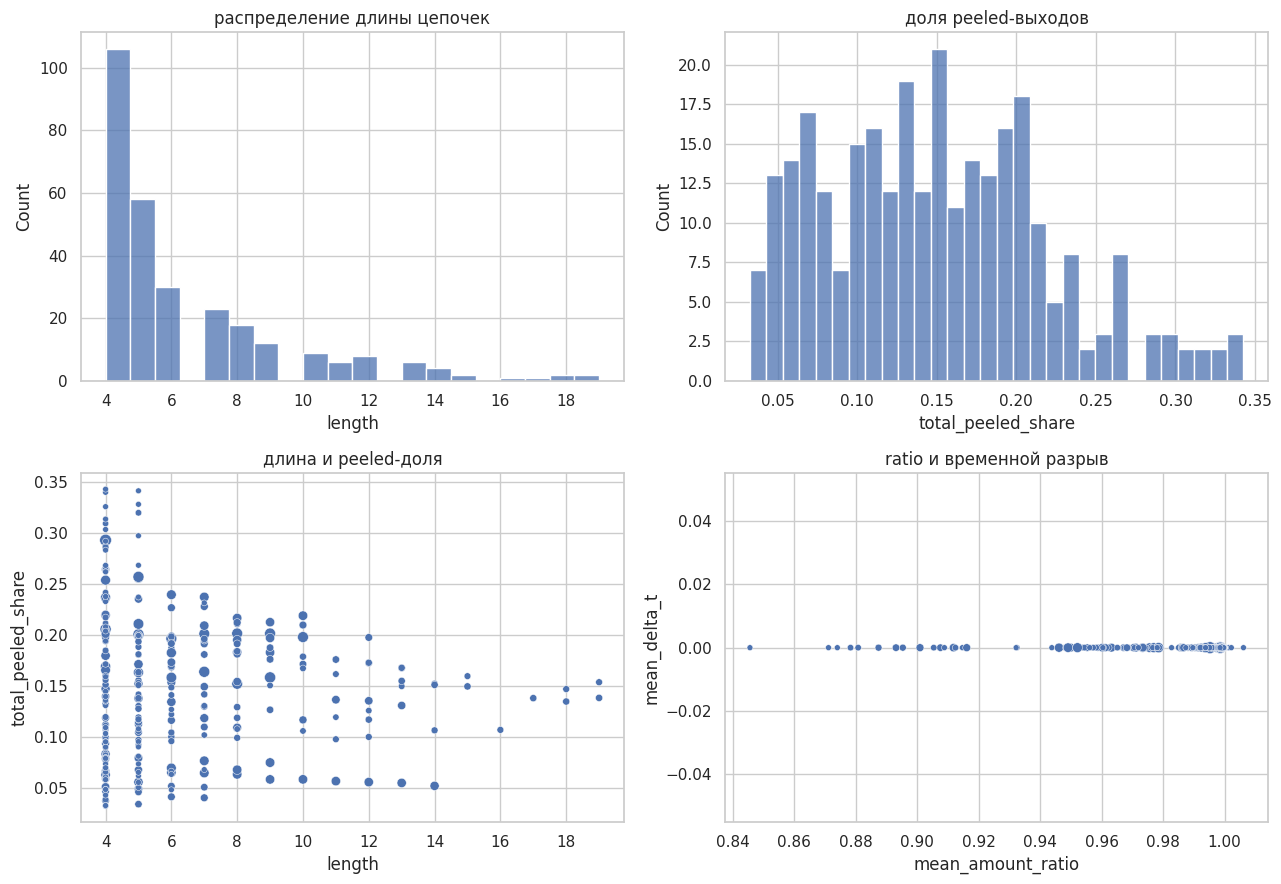

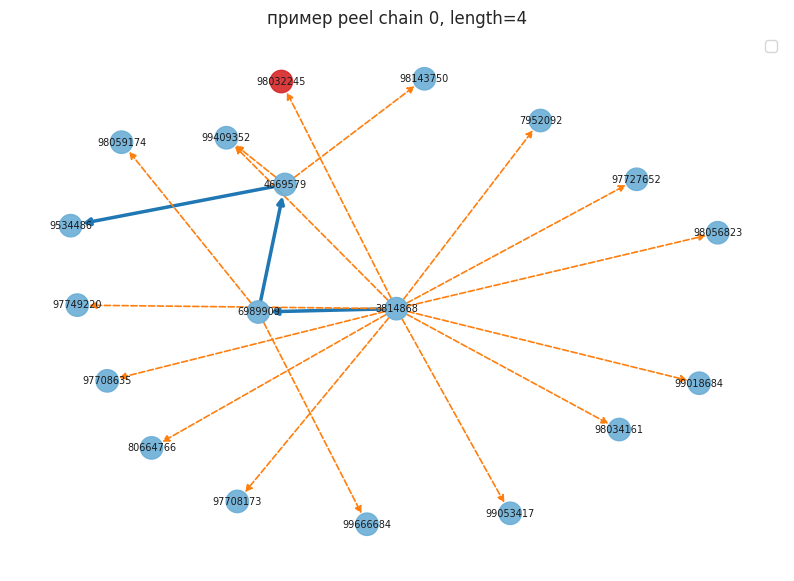

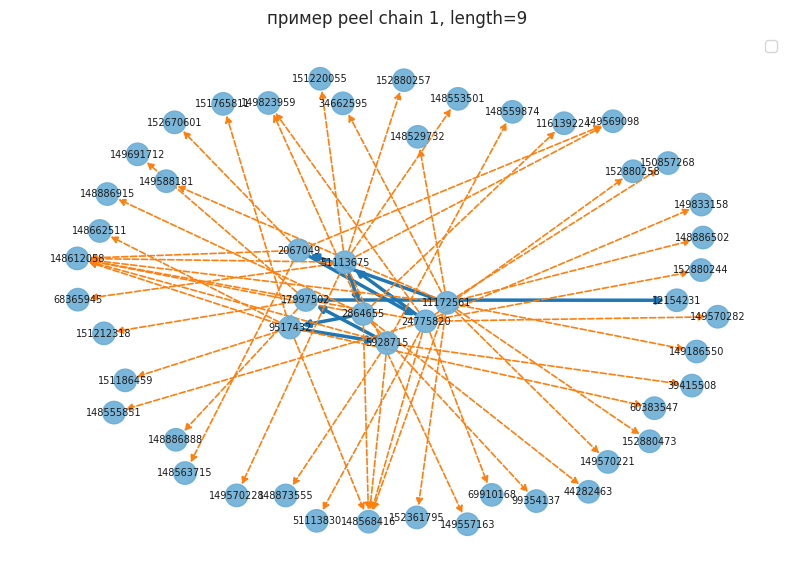

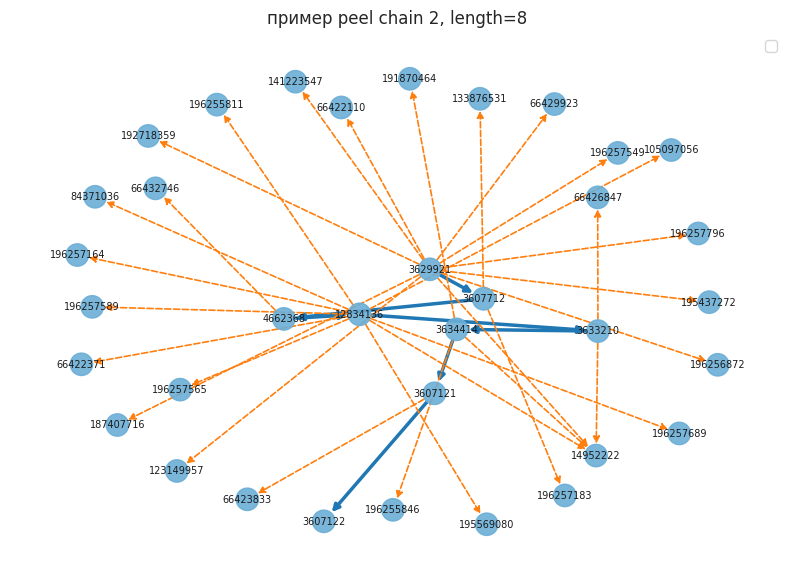

In [8]:
# вход: таблица цепочек; выход: обзорные распределения длины, peel-share, времени и ветвления.
def plot_chain_distributions(chain_table: pd.DataFrame) -> None:
    if chain_table.empty:
        print("chain table is empty")
        return

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    sns.histplot(chain_table["length"], bins=20, ax=axes[0, 0])
    axes[0, 0].set_title("распределение длины цепочек")

    sns.histplot(chain_table["total_peeled_share"], bins=30, ax=axes[0, 1])
    axes[0, 1].set_title("доля peeled-выходов")

    sns.scatterplot(
        data=chain_table,
        x="length",
        y="total_peeled_share",
        size="branching_factor",
        ax=axes[1, 0],
        legend=False,
    )
    axes[1, 0].set_title("длина и peeled-доля")

    sns.scatterplot(
        data=chain_table,
        x="mean_amount_ratio",
        y="mean_delta_t",
        size="length",
        ax=axes[1, 1],
        legend=False,
    )
    axes[1, 1].set_title("ratio и временной разрыв")

    plt.tight_layout()
    save_plot(fig, "peel_chain_distributions.png")


# вход: исходный граф и цепочка; выход: малый subgraph с основной линией и peel-ответвлениями.
def build_chain_visual_graph(graph: nx.DiGraph, chain: PeelChain) -> nx.DiGraph:
    nodes = set(chain.tx_ids)
    edges = []
    for step in chain.step_features:
        current_tx = step["current_tx"]
        main_tx = step["next_tx"]
        _, peel_txs = choose_main_and_peels(graph, current_tx)
        nodes.update(peel_txs)
        edges.append((current_tx, main_tx, "main"))
        edges.extend((current_tx, peel_tx, "peel") for peel_tx in peel_txs)

    subgraph = nx.DiGraph()
    for tx_id in nodes:
        subgraph.add_node(
            tx_id,
            time_step=node_time(graph, tx_id),
            label=graph.nodes[tx_id].get("label", "unknown"),
        )
    for source, target, edge_type in edges:
        subgraph.add_edge(source, target, edge_type=edge_type)
    return subgraph


def plot_peel_chain_example(graph: nx.DiGraph, chain: PeelChain) -> None:
    subgraph = build_chain_visual_graph(graph, chain)
    pos = nx.spring_layout(subgraph, seed=SEED, k=0.7)
    node_colors = [
        "#d62728" if subgraph.nodes[node].get("label") == "1" else "#6baed6"
        for node in subgraph.nodes
    ]
    main_edges = [
        edge for edge in subgraph.edges
        if subgraph.edges[edge].get("edge_type") == "main"
    ]
    peel_edges = [
        edge for edge in subgraph.edges
        if subgraph.edges[edge].get("edge_type") == "peel"
    ]

    fig = plt.figure(figsize=(10, 7))
    nx.draw_networkx_nodes(subgraph, pos, node_size=260, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(
        subgraph,
        pos,
        edgelist=main_edges,
        width=2.5,
        edge_color="#1f77b4",
        arrows=True,
        label="main path",
    )
    nx.draw_networkx_edges(
        subgraph,
        pos,
        edgelist=peel_edges,
        width=1.2,
        edge_color="#ff7f0e",
        arrows=True,
        style="dashed",
        label="peel outputs",
    )
    nx.draw_networkx_labels(subgraph, pos, font_size=7)
    plt.title(f"пример peel chain {chain.chain_id}, length={len(chain.tx_ids)}")
    plt.axis("off")
    plt.legend()
    save_plot(fig, f"peel_chain_example_{chain.chain_id}.png")


# вход: список цепочек; выход: самая длинная цепочка из всех найденных кандидатов.
def get_longest_chain(chains: list[PeelChain]) -> PeelChain | None:
    if not chains:
        return None
    return max(chains, key=lambda chain: (len(chain.tx_ids), len(chain.step_features)))


# вход: цепочка и исходный граф; выход: layout без пересечения основной линии цепочки.
def build_linear_chain_layout(
    graph: nx.DiGraph,
    chain: PeelChain,
    max_peels_per_step: int = 3,
) -> tuple[nx.DiGraph, dict[int, tuple[float, float]], dict[int, str], int]:
    subgraph = nx.DiGraph()
    pos = {}
    labels = {}
    hidden_peels = 0

    for idx, tx_id in enumerate(chain.tx_ids):
        subgraph.add_node(tx_id, node_role="main")
        pos[tx_id] = (float(idx), 0.0)
        labels[tx_id] = f"{idx}\n{tx_id}"

    for idx, step in enumerate(chain.step_features):
        current_tx = step["current_tx"]
        next_tx = step["next_tx"]
        if current_tx in subgraph and next_tx in subgraph:
            subgraph.add_edge(current_tx, next_tx, edge_type="main")

        _, peel_txs = choose_main_and_peels(graph, current_tx)
        visible_peels = peel_txs[:max_peels_per_step]
        hidden_peels += max(0, len(peel_txs) - len(visible_peels))
        for peel_idx, peel_tx in enumerate(visible_peels):
            if peel_tx not in subgraph:
                subgraph.add_node(peel_tx, node_role="peel")
                side = 1 if peel_idx % 2 == 0 else -1
                layer = peel_idx // 2 + 1
                x_shift = 0.20 * side * layer
                pos[peel_tx] = (float(idx) + x_shift, side * (1.1 + 0.45 * layer))
                labels[peel_tx] = str(peel_tx)
            subgraph.add_edge(current_tx, peel_tx, edge_type="peel")

    return subgraph, pos, labels, hidden_peels


# вход: самая длинная цепочка; выход: наглядная визуализация основной линии и peel-ответвлений.
def plot_longest_chain_linear(
    graph: nx.DiGraph,
    chain: PeelChain | None,
    max_peels_per_step: int = 3,
) -> None:
    if chain is None:
        print("longest chain is not found")
        return

    subgraph, pos, labels, hidden_peels = build_linear_chain_layout(
        graph,
        chain,
        max_peels_per_step=max_peels_per_step,
    )
    main_nodes = [node for node, attrs in subgraph.nodes(data=True) if attrs["node_role"] == "main"]
    peel_nodes = [node for node, attrs in subgraph.nodes(data=True) if attrs["node_role"] == "peel"]
    main_edges = [edge for edge in subgraph.edges if subgraph.edges[edge]["edge_type"] == "main"]
    peel_edges = [edge for edge in subgraph.edges if subgraph.edges[edge]["edge_type"] == "peel"]

    width = max(12, min(24, 1.2 * len(chain.tx_ids)))
    fig = plt.figure(figsize=(width, 7))
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        nodelist=main_nodes,
        node_size=620,
        node_color="#1f77b4",
        alpha=0.95,
        label="main chain nodes",
    )
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        nodelist=peel_nodes,
        node_size=260,
        node_color="#ffbf69",
        alpha=0.90,
        label="peel outputs",
    )
    nx.draw_networkx_edges(
        subgraph,
        pos,
        edgelist=main_edges,
        width=3.0,
        edge_color="#08306b",
        arrows=True,
        arrowsize=18,
        connectionstyle="arc3,rad=0.0",
        label="main path",
    )
    nx.draw_networkx_edges(
        subgraph,
        pos,
        edgelist=peel_edges,
        width=1.4,
        edge_color="#f28e2b",
        arrows=True,
        arrowsize=13,
        style="dashed",
        connectionstyle="arc3,rad=0.0",
        label="peel outputs",
    )
    nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=7)
    plt.title(
        "самая длинная peel chain на всех найденных данных: "
        f"chain_id={chain.chain_id}, length={len(chain.tx_ids)}"
    )
    plt.axis("off")
    plt.legend(loc="upper right")
    if hidden_peels:
        plt.figtext(
            0.01,
            0.01,
            f"скрыто peel-ответвлений для читаемости: {hidden_peels}",
            ha="left",
            fontsize=10,
        )
    plt.tight_layout()
    save_plot(fig, f"peel_chain_longest_{chain.chain_id}.png")

    display(
        pd.DataFrame({
            "position": list(range(len(chain.tx_ids))),
            "txId": chain.tx_ids,
            "time_step": [node_time(graph, tx_id) for tx_id in chain.tx_ids],
            "class": [graph.nodes[tx_id].get("label", "unknown") for tx_id in chain.tx_ids],
        })
    )


plot_chain_distributions(chain_df)
for chain in baseline_chains[:3]:
    plot_peel_chain_example(G, chain)

longest_chain = get_longest_chain(baseline_chains)
plot_longest_chain_linear(G, longest_chain, max_peels_per_step=3)

## 3. unsupervised 1: sequence autoencoder

Цепочка представляется как последовательность шаговых признаков. GRU-autoencoder восстанавливает эту последовательность, а `ae_error` используется как score аномальности.

In [9]:
# sequence autoencoder проверяет гипотезу: нетипичная динамика шагов цепочки дает высокий reconstruction error.
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("torch is not available")


# модель SequenceAutoencoder сжимает последовательность шагов и восстанавливает ее обратно.
class SequenceAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 32, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, input_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, hidden = self.encoder(x)
        latent = torch.tanh(self.to_latent(hidden[-1]))
        decoder_hidden = torch.tanh(self.from_latent(latent)).unsqueeze(0)
        zeros = torch.zeros_like(x)
        decoded, _ = self.decoder(zeros, decoder_hidden)
        return self.output(decoded)


# вход: padded-последовательности и mask; выход: reconstruction error для каждой цепочки.
def train_sequence_autoencoder(
    x_seq: np.ndarray,
    mask: np.ndarray,
    epochs: int = 25,
    batch_size: int = 64,
) -> np.ndarray:
    if not TORCH_AVAILABLE or len(x_seq) == 0:
        return np.zeros(len(x_seq))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_tensor = torch.tensor(x_seq, dtype=torch.float32)
    mask_tensor = torch.tensor(mask, dtype=torch.float32)
    dataset = TensorDataset(x_tensor, mask_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = SequenceAutoencoder(input_dim=x_seq.shape[-1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_x, batch_mask in loader:
            batch_x = batch_x.to(device)
            batch_mask = batch_mask.to(device)
            optimizer.zero_grad()
            reconstructed = model(batch_x)
            loss = ((reconstructed - batch_x) ** 2 * batch_mask.unsqueeze(-1)).sum()
            loss = loss / batch_mask.sum().clamp_min(1.0)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        if (epoch + 1) % 5 == 0:
            print(f"epoch {epoch + 1}: loss {np.mean(losses):.6f}")

    model.eval()
    with torch.no_grad():
        x_tensor = x_tensor.to(device)
        mask_tensor = mask_tensor.to(device)
        reconstructed = model(x_tensor)
        errors = ((reconstructed - x_tensor) ** 2 * mask_tensor.unsqueeze(-1)).sum(dim=(1, 2))
        errors = errors / mask_tensor.sum(dim=1).clamp_min(1.0)
    return errors.detach().cpu().numpy()


chain_df["ae_error"] = train_sequence_autoencoder(X_seq, seq_mask)
display(chain_df[["chain_id", "length", "total_peeled_share", "ae_error"]].head())

epoch 5: loss 4.028551
epoch 10: loss 4.203176
epoch 15: loss 3.732526
epoch 20: loss 2.735519
epoch 25: loss 2.624643


,chain_id,length,total_peeled_share,ae_error
0,0,4,0.169202,8.604623
1,1,9,0.158549,4.481131
2,2,8,0.183121,7.249594
3,3,7,0.201261,7.462428
4,4,7,0.164062,3.696948


## 4. unsupervised 2: feature-space anomaly detection

Агрегированные признаки цепочки образуют табличное пространство. Здесь используются Isolation Forest, LOF и PCA reconstruction error. Итоговый `tab_anom_score` — средний rank-score трёх методов.

In [10]:
# вход: сырые anomaly-score; выход: ранговая нормализация 0..1 для объединения методов.
def rank_score(values: np.ndarray) -> np.ndarray:
    series = pd.Series(values).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return series.rank(pct=True).to_numpy()


# вход: агрегированные признаки цепочек; выход: score от isolation forest, lof, dbscan и kmeans.
def compute_tabular_anomaly_scores(chain_table: pd.DataFrame) -> pd.DataFrame:
    if chain_table.empty:
        return chain_table

    x_tab = chain_table[AGG_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    x_scaled = StandardScaler().fit_transform(x_tab)

    if len(chain_table) < 5:
        chain_table["iforest_score"] = 0.0
        chain_table["lof_score"] = 0.0
        chain_table["pca_score"] = 0.0
        chain_table["tab_anom_score"] = 0.0
        return chain_table

    iforest = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=SEED,
    )
    chain_table["iforest_score"] = -iforest.fit_predict(x_scaled)
    chain_table["iforest_score"] = -iforest.score_samples(x_scaled)

    n_neighbors = min(20, max(2, len(chain_table) - 1))
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=False)
    lof.fit_predict(x_scaled)
    chain_table["lof_score"] = -lof.negative_outlier_factor_

    n_components = min(3, x_scaled.shape[1], max(1, len(chain_table) - 1))
    pca = PCA(n_components=n_components, random_state=SEED)
    x_reduced = pca.fit_transform(x_scaled)
    x_restored = pca.inverse_transform(x_reduced)
    chain_table["pca_score"] = np.mean((x_scaled - x_restored) ** 2, axis=1)

    rank_columns = ["iforest_score", "lof_score", "pca_score"]
    chain_table["tab_anom_score"] = np.mean(
        [rank_score(chain_table[col].to_numpy()) for col in rank_columns],
        axis=0,
    )
    return chain_table


chain_df = compute_tabular_anomaly_scores(chain_df)
display(
    chain_df[
        ["chain_id", "length", "total_peeled_share", "tab_anom_score"]
    ].sort_values("tab_anom_score", ascending=False).head(10)
)

,chain_id,length,total_peeled_share,tab_anom_score
44,44,5,0.056135,0.972222
46,46,4,0.063227,0.972222
15,15,6,0.069955,0.935185
105,105,5,0.049579,0.929398
86,86,19,0.153883,0.924769
70,70,19,0.138522,0.920139
57,57,4,0.083677,0.916667
18,18,4,0.292864,0.915509
1,1,9,0.158549,0.913194
229,229,5,0.199632,0.905093


## 5. unsupervised 3: subgraph encoder

Для каждой цепочки строится подграф `цепь + peel-выходы + 1-hop соседи`. Если доступны `torch` и `torch_geometric`, можно заменить этот блок на полноценный GraphSAGE/GIN. В текущей версии используется лёгкий self-supervised encoder: структурные и feature-pooling признаки подграфа с последующей PCA-компрессией и anomaly detection в embedding-пространстве.

In [11]:
# вход: цепочка и число hops; выход: subgraph цепочки с ближайшим графовым контекстом.
def build_expanded_chain_subgraph(
    graph: nx.DiGraph,
    chain: PeelChain,
    hops: int = 1,
) -> nx.DiGraph:
    nodes = set(chain.tx_ids)
    for step in chain.step_features:
        _, peel_txs = choose_main_and_peels(graph, step["current_tx"])
        nodes.update(peel_txs)

    frontier = set(nodes)
    for _ in range(hops):
        new_nodes = set()
        for tx_id in frontier:
            new_nodes.update(graph.predecessors(tx_id))
            new_nodes.update(graph.successors(tx_id))
        new_nodes -= nodes
        nodes.update(new_nodes)
        frontier = new_nodes

    return graph.subgraph(nodes).copy()


# вход: expanded subgraph; выход: компактный вектор структурных признаков для anomaly scoring.
def encode_subgraph_features(graph: nx.DiGraph, subgraph: nx.DiGraph) -> dict:
    node_list = list(subgraph.nodes)
    amount_values = np.array([node_amount(graph, tx_id) for tx_id in node_list], dtype=float)
    times = np.array([node_time(graph, tx_id) for tx_id in node_list], dtype=float)
    labels = [graph.nodes[tx_id].get("label", "unknown") for tx_id in node_list]

    density = nx.density(subgraph) if subgraph.number_of_nodes() > 1 else 0.0
    weak_components = nx.number_weakly_connected_components(subgraph)
    avg_degree = np.mean([deg for _, deg in subgraph.degree()]) if node_list else 0.0

    return {
        "sub_nodes": subgraph.number_of_nodes(),
        "sub_edges": subgraph.number_of_edges(),
        "sub_density": density,
        "sub_weak_components": weak_components,
        "sub_avg_degree": avg_degree,
        "sub_amount_mean": float(np.mean(amount_values)) if len(amount_values) else 0.0,
        "sub_amount_std": float(np.std(amount_values)) if len(amount_values) else 0.0,
        "sub_time_span": float(np.max(times) - np.min(times)) if len(times) else 0.0,
        "sub_illicit_share": float(np.mean([label == "1" for label in labels])) if labels else 0.0,
        "sub_unknown_share": float(np.mean([label == "unknown" for label in labels])) if labels else 0.0,
    }


# вход: граф и цепочки; выход: таблица subgraph-признаков и стандартизованная матрица embeddings.
def compute_subgraph_embeddings(
    graph: nx.DiGraph,
    chains: list[PeelChain],
) -> tuple[pd.DataFrame, np.ndarray]:
    rows = []
    for chain in tqdm(chains, desc="subgraph encoding"):
        subgraph = build_expanded_chain_subgraph(graph, chain, hops=1)
        row = encode_subgraph_features(graph, subgraph)
        row["chain_id"] = chain.chain_id
        rows.append(row)

    subgraph_df = pd.DataFrame(rows).fillna(0.0)
    if subgraph_df.empty:
        return subgraph_df, np.empty((0, 0))

    feature_cols = [col for col in subgraph_df.columns if col != "chain_id"]
    x_sub = StandardScaler().fit_transform(subgraph_df[feature_cols])
    n_components = min(8, x_sub.shape[1], max(1, len(subgraph_df) - 1))
    embeddings = PCA(n_components=n_components, random_state=SEED).fit_transform(x_sub)
    return subgraph_df, embeddings


def compute_embedding_anomaly_scores(embeddings: np.ndarray) -> np.ndarray:
    if len(embeddings) < 5:
        return np.zeros(len(embeddings))

    iforest = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=SEED,
    )
    isolation_score = -iforest.fit(embeddings).score_samples(embeddings)

    n_neighbors = min(10, max(2, len(embeddings) - 1))
    neighbors = NearestNeighbors(n_neighbors=n_neighbors).fit(embeddings)
    distances, _ = neighbors.kneighbors(embeddings)
    density_score = distances[:, -1]

    return np.mean(
        [rank_score(isolation_score), rank_score(density_score)],
        axis=0,
    )


subgraph_df, Z_chain = compute_subgraph_embeddings(G, baseline_chains)
if not subgraph_df.empty:
    chain_df = chain_df.merge(subgraph_df, on="chain_id", how="left")
chain_df["gnn_anom_score"] = compute_embedding_anomaly_scores(Z_chain)
display(chain_df[["chain_id", "length", "gnn_anom_score"]].head())

subgraph encoding:   0%|          | 0/288 [00:00<?, ?it/s]

,chain_id,length,gnn_anom_score
0,0,4,0.510417
1,1,9,0.901042
2,2,8,0.420139
3,3,7,0.217014
4,4,7,0.817708


## 6. сравнение подходов без ручной разметки

Метрики сравниваются через rank-нормализацию. Для каждого метода берём `top-K` цепочек и считаем пересечения: baseline, sequence autoencoder, tabular anomaly detection и subgraph anomaly detection.

График пересечения top-100 цепочек показывает согласованность разных способов поиска peel-chain кандидатов. Каждая ячейка heatmap равна числу цепочек, которые одновременно попали в top-100 двух методов. Диагональ равна 100, потому что метод полностью совпадает сам с собой.

Высокое пересечение означает, что методы выделяют похожие подозрительные структуры и реагируют на один и тот же сигнал в данных. Например, сильное пересечение sequence autoencoder и tabular anomaly detection показывает, что нетипичная последовательная форма цепочки согласуется с агрегированными chain-level признаками. Низкое пересечение, наоборот, означает, что метод находит другой тип кандидатов: например, subgraph anomaly может выбирать цепочки не по форме последовательности, а по локальному графовому окружению.

Этот график не является метрикой качества в терминах `licit / illicit`, потому что ручной разметки peel-chain нет. Он используется как unsupervised sanity check: если все методы полностью совпадают, они не дают нового сигнала; если пересечения частичные, ensemble может объединять разные представления аномальности цепочек.

,baseline,sequence_ae,tabular,subgraph,ensemble
baseline,100.0,49.0,58.0,30.0,51.0
sequence_ae,49.0,100.0,75.0,44.0,80.0
tabular,58.0,75.0,100.0,50.0,85.0
subgraph,30.0,44.0,50.0,100.0,63.0
ensemble,51.0,80.0,85.0,63.0,100.0


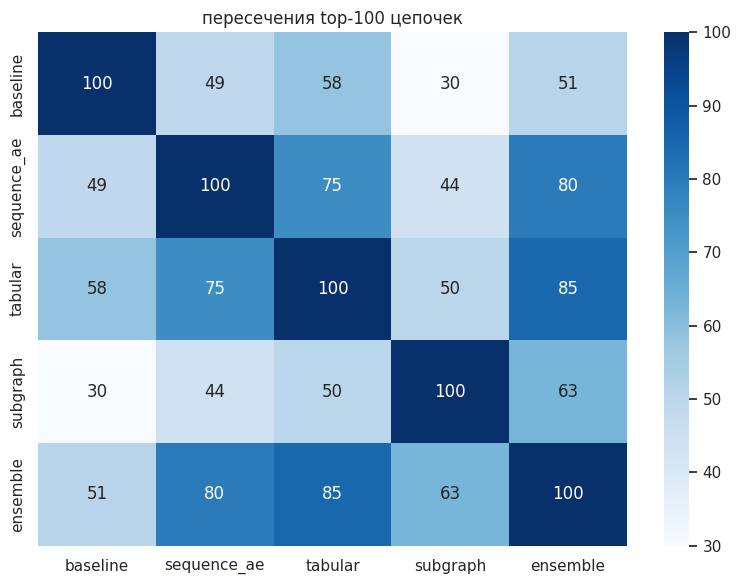

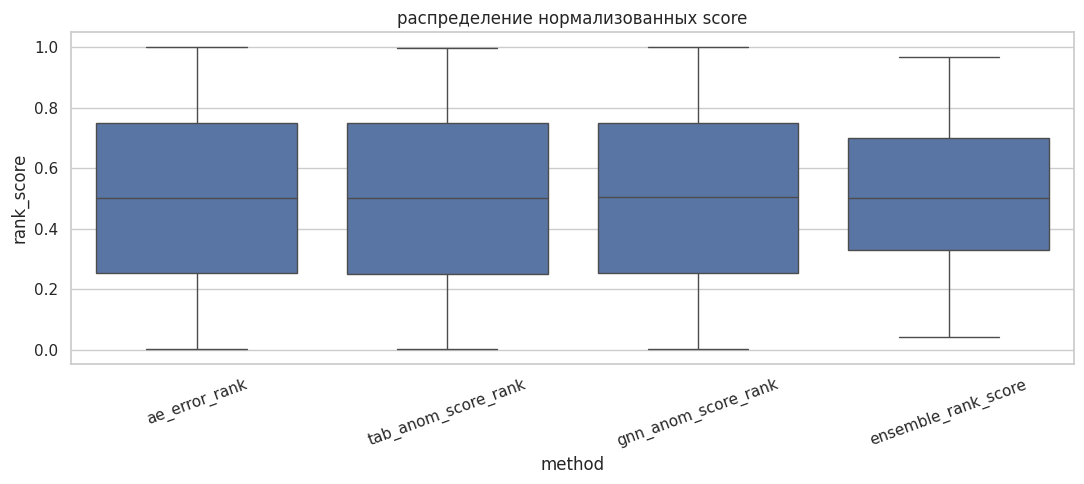

In [12]:
# вход: таблица score; выход: те же цепочки с rank-score и ensemble-оценкой.
def add_rank_scores(chain_table: pd.DataFrame) -> pd.DataFrame:
    score_columns = ["ae_error", "tab_anom_score", "gnn_anom_score"]
    for col in score_columns:
        if col not in chain_table.columns:
            chain_table[col] = 0.0
        chain_table[f"{col}_rank"] = rank_score(chain_table[col].to_numpy())

    chain_table["ensemble_rank_score"] = chain_table[
        [f"{col}_rank" for col in score_columns]
    ].mean(axis=1)
    return chain_table


# вход: score-колонка и k; выход: множество id самых подозрительных цепочек.
def top_k_ids(chain_table: pd.DataFrame, score_col: str, k: int) -> set[int]:
    if chain_table.empty:
        return set()
    return set(
        chain_table.sort_values(score_col, ascending=False)
        .head(min(k, len(chain_table)))["chain_id"]
        .astype(int)
    )


# вход: top-k множества разных методов; выход: матрица пересечений для оценки согласованности.
def build_overlap_matrix(method_sets: dict[str, set[int]]) -> pd.DataFrame:
    methods = list(method_sets)
    matrix = pd.DataFrame(index=methods, columns=methods, dtype=int)
    for left in methods:
        for right in methods:
            matrix.loc[left, right] = len(method_sets[left] & method_sets[right])
    return matrix


chain_df = add_rank_scores(chain_df)
method_sets = {
    "baseline": set(chain_df["chain_id"].astype(int).head(min(TOP_K, len(chain_df)))),
    "sequence_ae": top_k_ids(chain_df, "ae_error_rank", TOP_K),
    "tabular": top_k_ids(chain_df, "tab_anom_score_rank", TOP_K),
    "subgraph": top_k_ids(chain_df, "gnn_anom_score_rank", TOP_K),
    "ensemble": top_k_ids(chain_df, "ensemble_rank_score", TOP_K),
}

overlap_df = build_overlap_matrix(method_sets)
display(overlap_df)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(overlap_df.astype(int), annot=True, fmt="d", cmap="Blues")
plt.title(f"пересечения top-{TOP_K} цепочек")
plt.tight_layout()
save_plot(fig, "peel_topk_overlap_heatmap.png")

score_cols = [
    "ae_error_rank",
    "tab_anom_score_rank",
    "gnn_anom_score_rank",
    "ensemble_rank_score",
]
plot_scores = chain_df.melt(
    id_vars=["chain_id"],
    value_vars=score_cols,
    var_name="method",
    value_name="rank_score",
)
fig = plt.figure(figsize=(11, 5))
sns.boxplot(data=plot_scores, x="method", y="rank_score")
plt.xticks(rotation=20)
plt.title("распределение нормализованных score")
plt.tight_layout()
save_plot(fig, "peel_rank_score_distribution.png")

## 6.1 качественный анализ top-цепочек

Выводим несколько кандидатов из каждого метода. Это нужно для визуальной проверки: похожа ли найденная структура на peel chain и какие цепочки модель находит вне baseline-логики.

sequence autoencoder


,chain_id,length,total_peeled_share,mean_delta_t,branching_factor,ae_error_rank
208,208,4,0.201124,0.0,3.666667,1.000000
54,54,5,0.198867,0.0,3.750000,0.996528


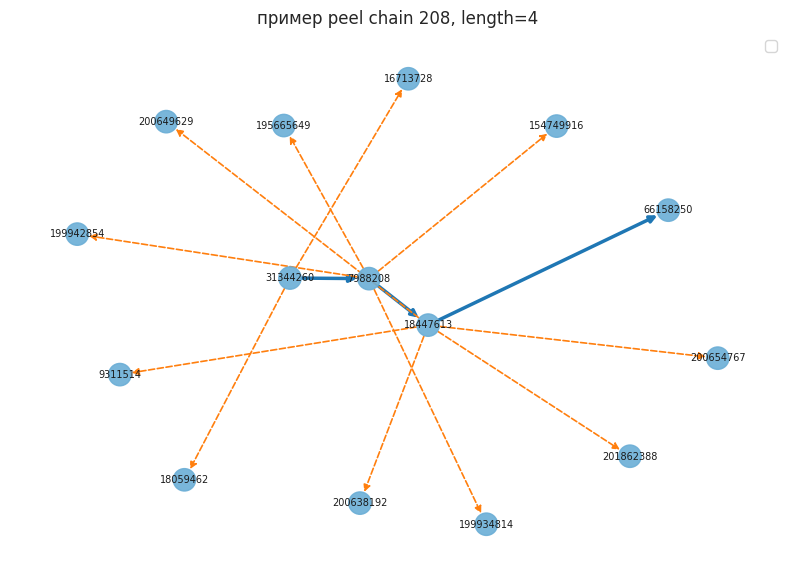

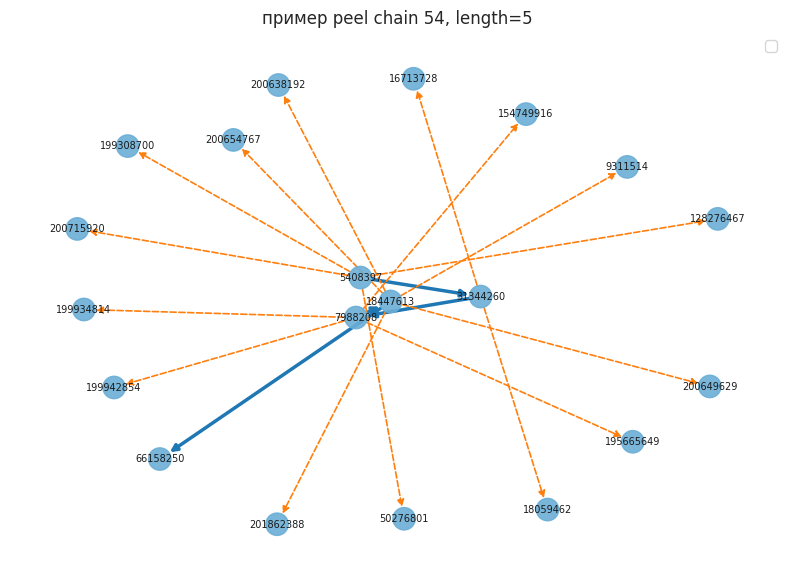

tabular anomaly


,chain_id,length,total_peeled_share,mean_delta_t,branching_factor,tab_anom_score_rank
44,44,5,0.056135,0.0,4.250000,0.998264
46,46,4,0.063227,0.0,4.333333,0.998264


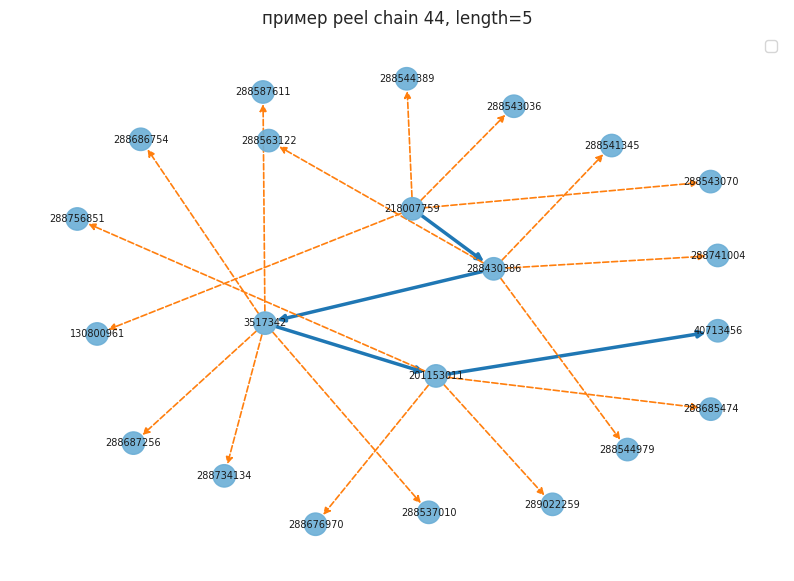

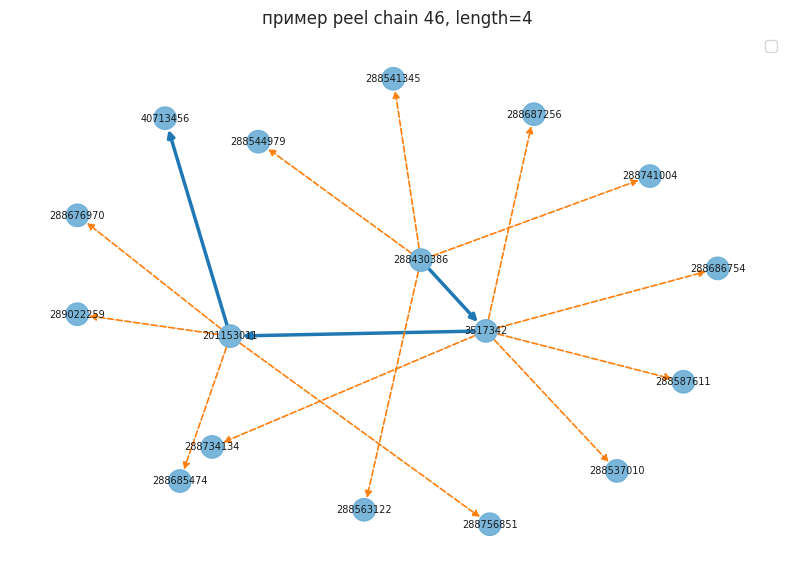

subgraph anomaly


,chain_id,length,total_peeled_share,mean_delta_t,branching_factor,gnn_anom_score_rank
99,99,4,0.112333,0.0,2.333333,1.000000
91,91,4,0.264211,0.0,3.000000,0.993056


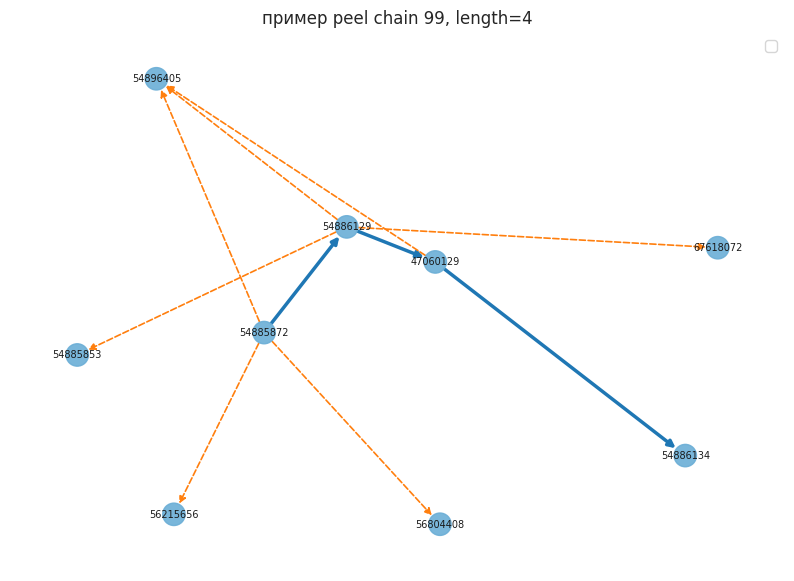

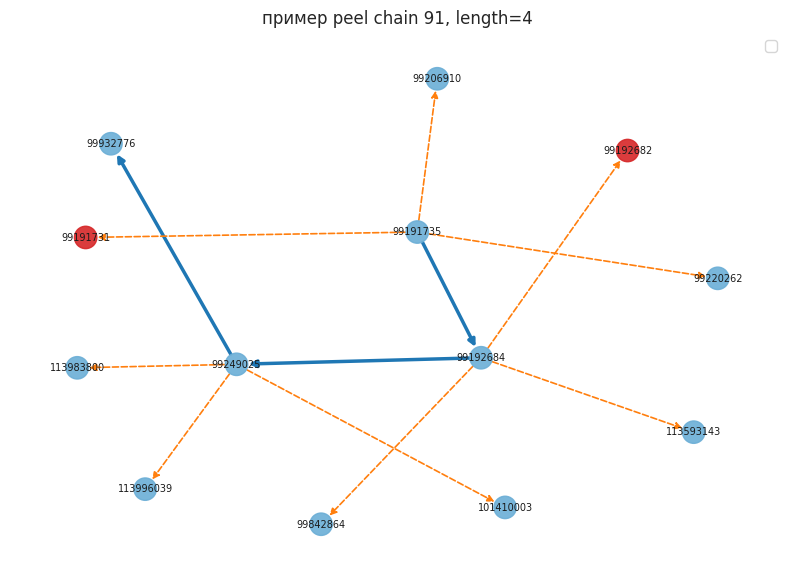

ensemble


,chain_id,length,total_peeled_share,mean_delta_t,branching_factor,ensemble_rank_score
57,57,4,0.083677,0.0,4.00,0.967593
105,105,5,0.049579,0.0,3.25,0.919560


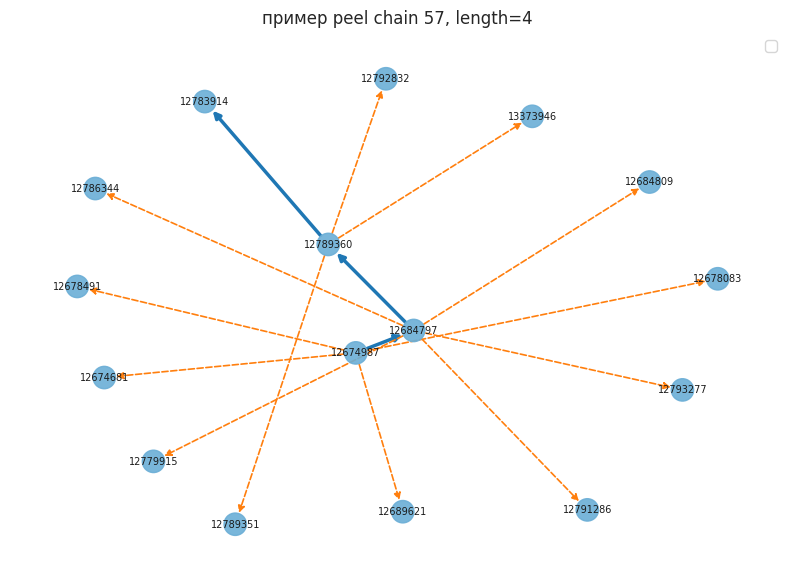

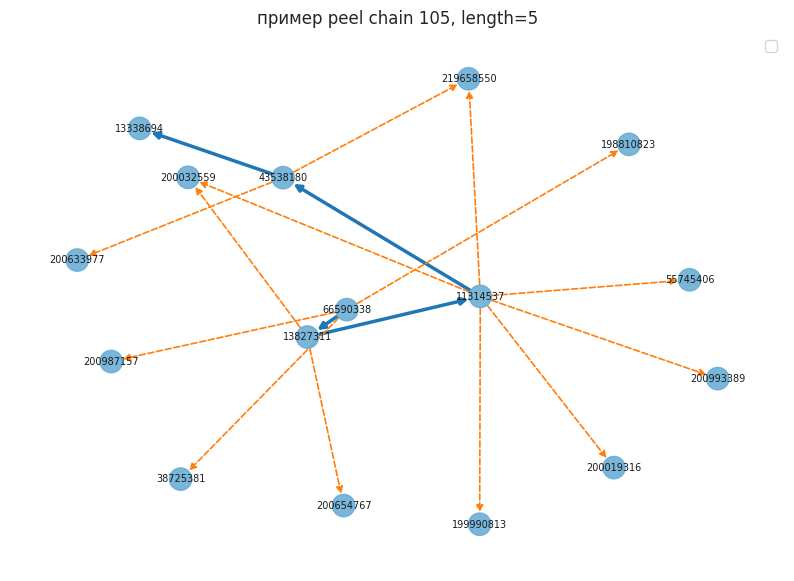

In [13]:
# вход: score-колонка; выход: таблица и графики top-цепочек для качественной проверки.
def show_top_chains(
    chain_table: pd.DataFrame,
    chains: list[PeelChain],
    score_col: str,
    n_examples: int = 3,
) -> None:
    if chain_table.empty:
        print("chain table is empty")
        return

    chain_lookup = {chain.chain_id: chain for chain in chains}
    columns = [
        "chain_id",
        "length",
        "total_peeled_share",
        "mean_delta_t",
        "branching_factor",
        score_col,
    ]
    top_rows = chain_table.sort_values(score_col, ascending=False).head(n_examples)
    display(top_rows[columns])

    for chain_id in top_rows["chain_id"].astype(int):
        chain = chain_lookup.get(chain_id)
        if chain is not None:
            plot_peel_chain_example(G, chain)


for method_name, score_col in [
    ("sequence autoencoder", "ae_error_rank"),
    ("tabular anomaly", "tab_anom_score_rank"),
    ("subgraph anomaly", "gnn_anom_score_rank"),
    ("ensemble", "ensemble_rank_score"),
]:
    print(method_name)
    show_top_chains(chain_df, baseline_chains, score_col, n_examples=2)

## 7. экспорт фичей для node classification

Переводим chain-level результаты в признаки уровня транзакций. На выходе получается таблица `txId + peel_*`, которую можно присоединять к основному classification notebook.

In [14]:
# вход: узлы, цепочки и score; выход: node-level признаки участия в peel-chain для классификации.
def build_node_peel_features(
    nodes: pd.DataFrame,
    chains: list[PeelChain],
    chain_table: pd.DataFrame,
) -> pd.DataFrame:
    score_lookup = chain_table.set_index("chain_id").to_dict("index")
    # rows аккумулирует признаки по txId, потому что один узел может входить в несколько цепочек.
    rows = defaultdict(lambda: {
        "peel_in_chain_any": 0,
        "peel_max_chain_length": 0,
        "peel_start_count": 0,
        "peel_middle_count": 0,
        "peel_end_count": 0,
        "peel_chain_count": 0,
        "peel_baseline_chain_participation": 0,
        "_ae_values": [],
        "_tab_values": [],
        "_gnn_values": [],
    })

    for chain in chains:
        chain_scores = score_lookup.get(chain.chain_id, {})
        for pos, tx_id in enumerate(chain.tx_ids):
            row = rows[tx_id]
            row["peel_in_chain_any"] = 1
            row["peel_chain_count"] += 1
            row["peel_max_chain_length"] = max(row["peel_max_chain_length"], len(chain.tx_ids))
            row["peel_baseline_chain_participation"] = max(
                row["peel_baseline_chain_participation"],
                chain.baseline_flag,
            )
            if pos == 0:
                row["peel_start_count"] += 1
            elif pos == len(chain.tx_ids) - 1:
                row["peel_end_count"] += 1
            else:
                row["peel_middle_count"] += 1
            row["_ae_values"].append(chain_scores.get("ae_error", 0.0))
            row["_tab_values"].append(chain_scores.get("tab_anom_score", 0.0))
            row["_gnn_values"].append(chain_scores.get("gnn_anom_score", 0.0))

    feature_rows = []
    for tx_id in nodes["txId"]:
        row = rows[int(tx_id)]
        ae_values = row.pop("_ae_values")
        tab_values = row.pop("_tab_values")
        gnn_values = row.pop("_gnn_values")
        row.update({
            "txId": int(tx_id),
            "peel_mean_ae_error": float(np.mean(ae_values)) if ae_values else 0.0,
            "peel_max_ae_error": float(np.max(ae_values)) if ae_values else 0.0,
            "peel_mean_tab_anom_score": float(np.mean(tab_values)) if tab_values else 0.0,
            "peel_mean_gnn_anom_score": float(np.mean(gnn_values)) if gnn_values else 0.0,
        })
        feature_rows.append(row)

    peel_features = pd.DataFrame(feature_rows)
    ordered_columns = ["txId"] + sorted([col for col in peel_features.columns if col != "txId"])
    return peel_features[ordered_columns]


peel_features_df = build_node_peel_features(nodes_df, baseline_chains, chain_df)
peel_features_path = OUTPUT_DIR / "peel_features.csv"
chain_scores_path = OUTPUT_DIR / "peel_chain_scores.csv"

peel_features_df.to_csv(peel_features_path, index=False)
chain_df.drop(columns=["tx_ids"], errors="ignore").to_csv(chain_scores_path, index=False)

display(peel_features_df.head())
print(f"saved peel features: {peel_features_path}")
print(f"saved chain scores: {chain_scores_path}")

,txId,peel_baseline_chain_participation,peel_chain_count,peel_end_count,peel_in_chain_any,peel_max_ae_error,peel_max_chain_length,peel_mean_ae_error,peel_mean_gnn_anom_score,peel_mean_tab_anom_score,peel_middle_count,peel_start_count
0,230425980,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0
1,5530458,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0
2,232022460,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0
3,232438397,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0
4,230460314,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0


saved peel features: ../outputs/peel_chains/peel_features.csv
saved chain scores: ../outputs/peel_chains/peel_chain_scores.csv


## 8. как сравнить методы без ручной разметки

Так как ручной разметки peel chains нет, нельзя честно сказать, что один unsupervised-метод лучше по `precision` или `recall`. Поэтому сравнение делается по косвенным критериям:

- согласие с baseline: метод находит цепочки, похожие на строгую эвристику;
- согласие с другими методами: независимые подходы выбирают одни и те же top-кандидаты;
- качество top-кандидатов: у top-цепочек выше длина, peeled-доля, branching и компактные временные интервалы;
- уникальность: метод даёт кандидатов, которых нет у baseline и других моделей;
- downstream-проверка: `peel_*` признаки улучшают node classification в отдельном ноутбуке.

Практически лучший метод здесь — не один score, а `ensemble_rank_score`: он устойчивее, потому что усредняет разные взгляды на аномальность цепочки.

,method,top_k,baseline_overlap,ensemble_overlap,unique_vs_baseline,median_length,median_peeled_share,median_branching,median_delta_t,score_median
0,sequence_ae,100,49,80,51,5.0,0.171303,3.916667,0.0,0.828125
1,tabular,100,58,85,42,6.0,0.141703,3.916667,0.0,0.828125
2,subgraph,100,30,63,70,4.5,0.095798,1.500000,0.0,0.828125
3,ensemble,100,51,100,49,5.0,0.137422,3.450000,0.0,0.745370


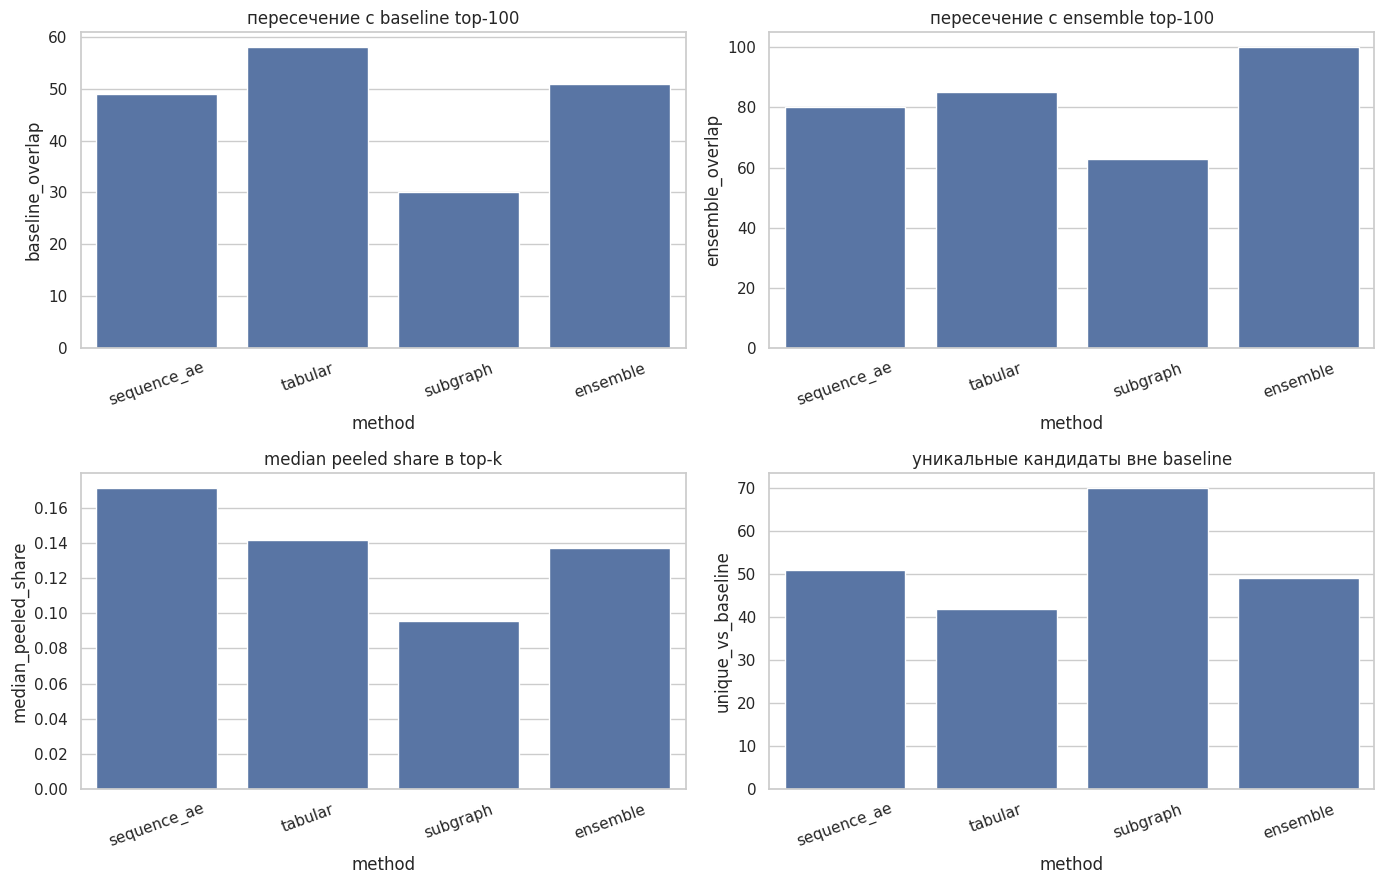

In [15]:
# вход: score-методы и top-k множества; выход: сводка качества без ручной разметки цепочек.
def summarize_method_quality(
    chain_table: pd.DataFrame,
    method_score_map: dict[str, str],
    method_sets: dict[str, set[int]],
    k: int,
) -> pd.DataFrame:
    rows = []
    # baseline_set и ensemble_set служат ориентирами: совпадение с правилом и консенсусом методов.
    baseline_set = method_sets.get("baseline", set())
    ensemble_set = method_sets.get("ensemble", set())

    for method_name, score_col in method_score_map.items():
        top_ids = top_k_ids(chain_table, score_col, k)
        top_rows = chain_table[chain_table["chain_id"].isin(top_ids)]
        rows.append({
            "method": method_name,
            "top_k": len(top_ids),
            "baseline_overlap": len(top_ids & baseline_set),
            "ensemble_overlap": len(top_ids & ensemble_set),
            "unique_vs_baseline": len(top_ids - baseline_set),
            "median_length": top_rows["length"].median(),
            "median_peeled_share": top_rows["total_peeled_share"].median(),
            "median_branching": top_rows["branching_factor"].median(),
            "median_delta_t": top_rows["mean_delta_t"].median(),
            "score_median": top_rows[score_col].median(),
        })
    return pd.DataFrame(rows)


method_score_map = {
    "sequence_ae": "ae_error_rank",
    "tabular": "tab_anom_score_rank",
    "subgraph": "gnn_anom_score_rank",
    "ensemble": "ensemble_rank_score",
}

method_quality_df = summarize_method_quality(
    chain_df,
    method_score_map,
    method_sets,
    TOP_K,
)
display(method_quality_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.barplot(
    data=method_quality_df,
    x="method",
    y="baseline_overlap",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"пересечение с baseline top-{TOP_K}")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=method_quality_df,
    x="method",
    y="ensemble_overlap",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"пересечение с ensemble top-{TOP_K}")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=method_quality_df,
    x="method",
    y="median_peeled_share",
    ax=axes[1, 0],
)
axes[1, 0].set_title("median peeled share в top-k")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=method_quality_df,
    x="method",
    y="unique_vs_baseline",
    ax=axes[1, 1],
)
axes[1, 1].set_title("уникальные кандидаты вне baseline")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
save_plot(fig, "peel_method_quality_summary.png")

## 9. распределения новых peel-признаков

Проверяем, как выглядят признаки, которые будут добавлены к данным для node classification. Важно отдельно смотреть все узлы и только узлы, попавшие хотя бы в одну peel chain: большинство транзакций не участвует в цепочках, поэтому распределения сильно разрежены.

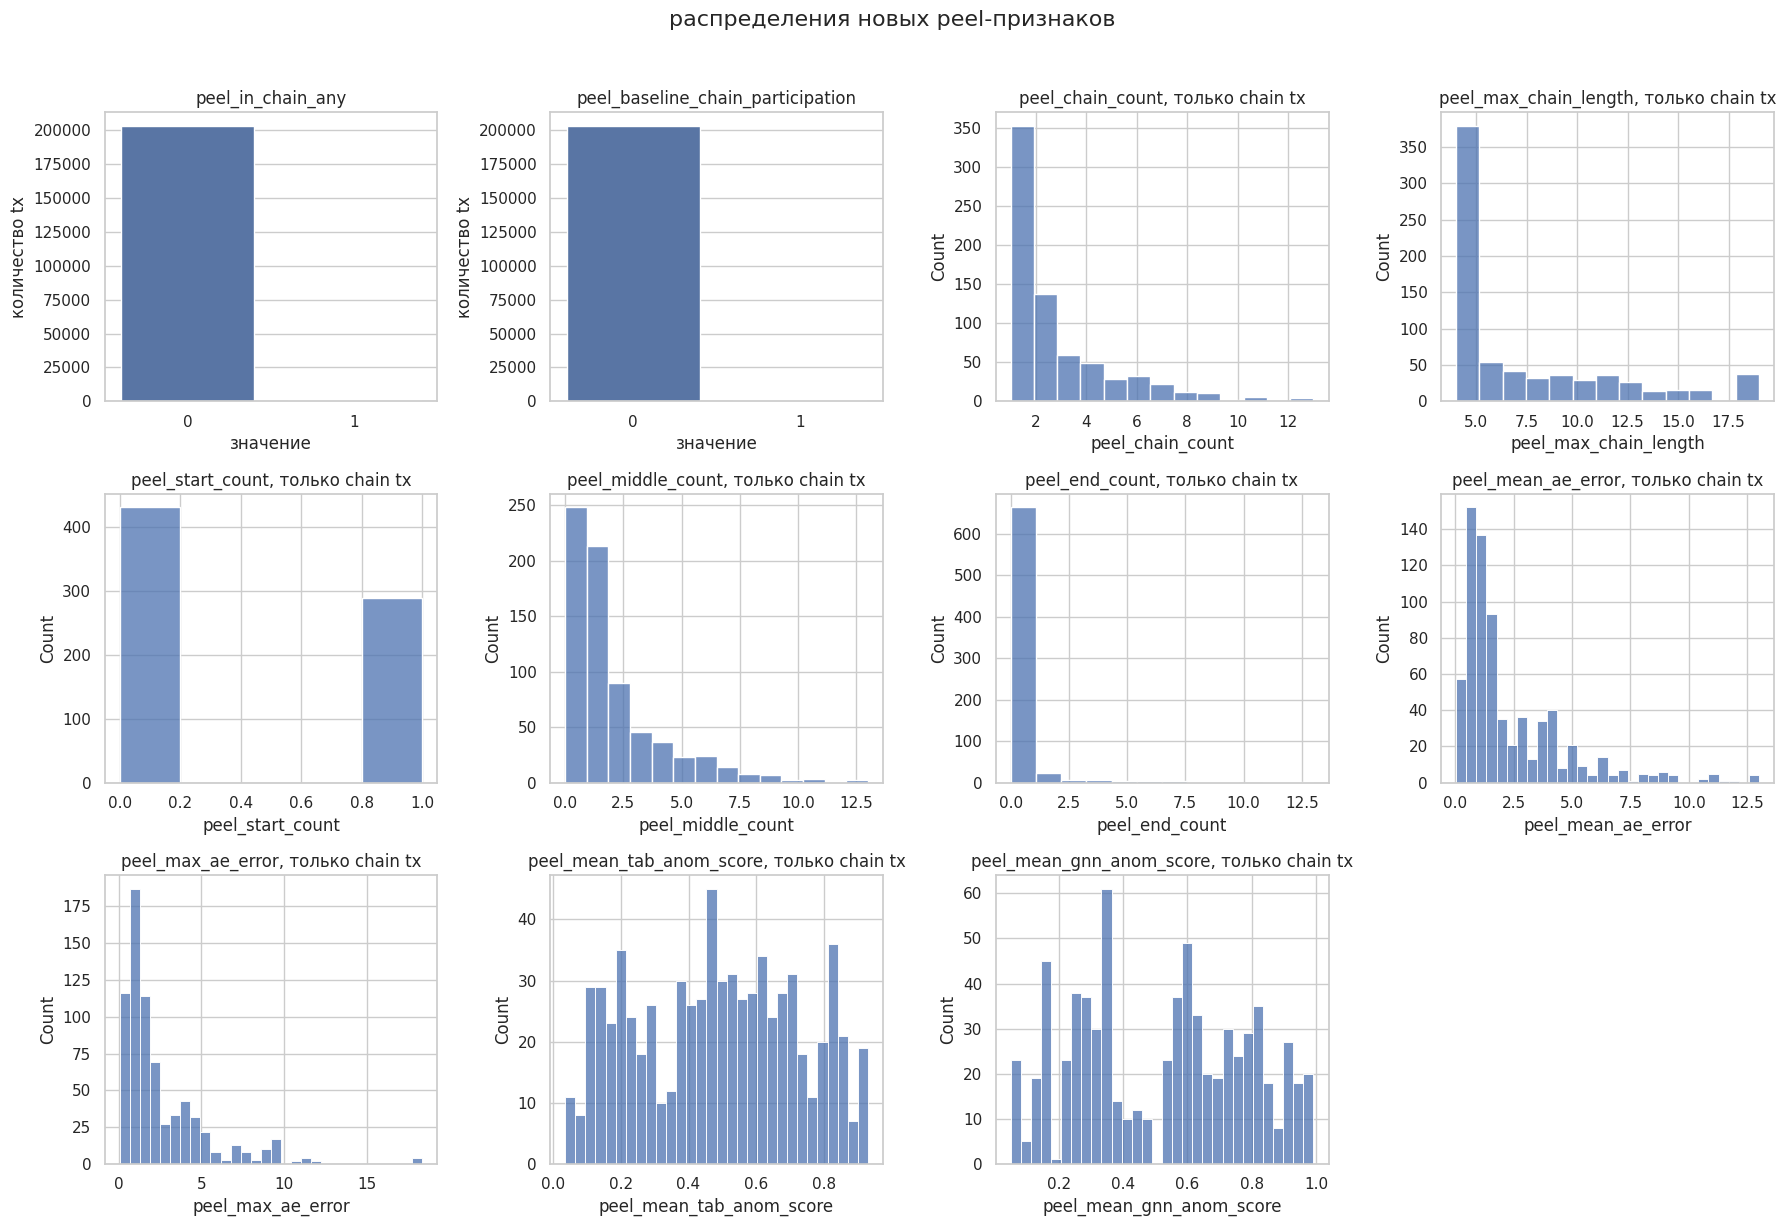

,label,tx_count,peel_tx_share,mean_chain_count,mean_ae_error,mean_tab_score,mean_gnn_score
0,1,4545,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,42019,0.003475,0.011162,0.013868,0.002457,0.002247
2,unknown,157205,0.003639,0.008657,0.007014,0.001553,0.001770


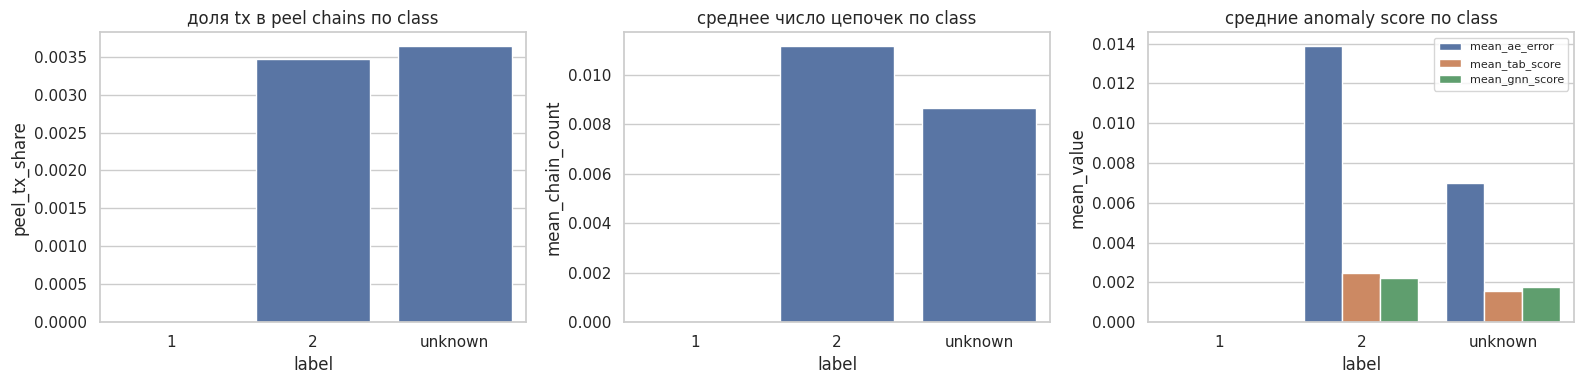

In [16]:
# вход: node-level peel-признаки; выход: распределения бинарных, счетных и score-признаков.
def plot_peel_feature_distributions(peel_features: pd.DataFrame) -> None:
    plot_df = peel_features.copy()
    binary_cols = [
        "peel_in_chain_any",
        "peel_baseline_chain_participation",
    ]
    count_cols = [
        "peel_chain_count",
        "peel_max_chain_length",
        "peel_start_count",
        "peel_middle_count",
        "peel_end_count",
    ]
    score_cols = [
        "peel_mean_ae_error",
        "peel_max_ae_error",
        "peel_mean_tab_anom_score",
        "peel_mean_gnn_anom_score",
    ]

    active_df = plot_df[plot_df["peel_in_chain_any"] == 1]
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.ravel()

    for idx, col in enumerate(binary_cols):
        counts = plot_df[col].value_counts().sort_index()
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].set_xlabel("значение")
        axes[idx].set_ylabel("количество tx")

    for offset, col in enumerate(count_cols, start=len(binary_cols)):
        sns.histplot(
            active_df[col],
            bins=min(30, max(5, int(active_df[col].nunique()))),
            ax=axes[offset],
        )
        axes[offset].set_title(f"{col}, только chain tx")
        axes[offset].set_xlabel(col)

    for offset, col in enumerate(score_cols, start=len(binary_cols) + len(count_cols)):
        sns.histplot(
            active_df[col],
            bins=30,
            ax=axes[offset],
        )
        axes[offset].set_title(f"{col}, только chain tx")
        axes[offset].set_xlabel(col)

    for ax in axes[len(binary_cols) + len(count_cols) + len(score_cols):]:
        ax.axis("off")

    plt.suptitle("распределения новых peel-признаков", y=1.02, fontsize=16)
    plt.tight_layout()
    save_plot(fig, "peel_node_feature_distributions.png")


# вход: peel-признаки и метки узлов; выход: сравнение активности peel-pattern по классам.
def plot_peel_features_by_label(
    peel_features: pd.DataFrame,
    nodes: pd.DataFrame,
) -> None:
    label_df = peel_features.merge(nodes[["txId", "label"]], on="txId", how="left")
    label_df["label"] = label_df["label"].fillna("unknown").astype(str)

    summary = (
        label_df.groupby("label")
        .agg(
            tx_count=("txId", "count"),
            peel_tx_share=("peel_in_chain_any", "mean"),
            mean_chain_count=("peel_chain_count", "mean"),
            mean_ae_error=("peel_mean_ae_error", "mean"),
            mean_tab_score=("peel_mean_tab_anom_score", "mean"),
            mean_gnn_score=("peel_mean_gnn_anom_score", "mean"),
        )
        .reset_index()
    )
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.barplot(data=summary, x="label", y="peel_tx_share", ax=axes[0])
    axes[0].set_title("доля tx в peel chains по class")

    sns.barplot(data=summary, x="label", y="mean_chain_count", ax=axes[1])
    axes[1].set_title("среднее число цепочек по class")

    score_summary = summary.melt(
        id_vars="label",
        value_vars=["mean_ae_error", "mean_tab_score", "mean_gnn_score"],
        var_name="score",
        value_name="mean_value",
    )
    sns.barplot(data=score_summary, x="label", y="mean_value", hue="score", ax=axes[2])
    axes[2].set_title("средние anomaly score по class")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    save_plot(fig, "peel_features_by_label.png")


plot_peel_feature_distributions(peel_features_df)
plot_peel_features_by_label(peel_features_df, nodes_df)

In [ ]:
# архивируем все сохранённые PNG-визуализации для скачивания из Kaggle output.
archive_path = shutil.make_archive(
    str(KAGGLE_WORKING / "peel_visualizations_png"),
    "zip",
    VIS_DIR,
)

print(f"visualization png directory: {VIS_DIR}")
print(f"visualization png archive: {archive_path}")

## вывод

Ноутбук проверяет peel chains как отдельную задачу поиска паттернов, а не как классификацию вершин. Rule-based baseline даёт интерпретируемую опору, sequence/table/subgraph score показывают разные виды аномальности, а итоговые `peel_*` признаки можно использовать в основном пайплайне node classification.